# Classificazione di Suoni Urbani con Cross-Validation

Questo notebook implementa l'addestramento e la valutazione di un modello per la classificazione di suoni urbani utilizzando spettrogrammi Mel come feature. Viene utilizzata una tecnica di k-fold cross-validation per garantire risultati robusti e evitare problemi di data leakage.

## 1. Importazione delle Librerie Necessarie

Importiamo TensorFlow e le altre librerie necessarie per il caricamento dei dati, l'addestramento del modello e la visualizzazione dei risultati.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold

# Impostazioni per riproducibilità
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Verifica disponibilità GPU
print("Dispositivi TensorFlow disponibili:", tf.config.list_physical_devices())
print("Utilizzo GPU:", tf.test.is_gpu_available())
print("Versione TensorFlow:", tf.__version__)

Dispositivi TensorFlow disponibili: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Utilizzo GPU: False
Versione TensorFlow: 2.19.0


## 2. Caricamento e Preparazione dei Dati

I dati sono già preelaborati e salvati in file .npz suddivisi in fold. Ogni file contiene gli spettrogrammi Mel e le relative etichette. Per prima cosa, identifichiamo tutti i file di fold disponibili e creiamo un elenco di percorsi file.

In [3]:
# Definire il percorso della directory contenente i folder dei dati
features_dir = "../data/processed/features"

# Trovare tutti i file .npz nelle cartelle fold
fold_files = glob.glob(os.path.join(features_dir, "fold*/*.npz"))
print(f"Trovati {len(fold_files)} file di fold")

# Se non trova file, verifichiamo percorsi alternativi
if len(fold_files) == 0:
    # Prova a cercare in altre posizioni comuni
    alternative_paths = [
        "../features",
        "../../data/processed/features",
        "../data/features",
        "."
    ]
    
    for path in alternative_paths:
        test_files = glob.glob(os.path.join(path, "fold*/*.npz"))
        if len(test_files) > 0:
            print(f"Trovati {len(test_files)} file in percorso alternativo: {path}")
            features_dir = path
            fold_files = test_files
            break

# Visualizza la struttura delle cartelle
print(f"\nStruttura delle cartelle:")
all_dirs = glob.glob(os.path.join(features_dir, "fold*"))
for dir in all_dirs:
    count = len(glob.glob(os.path.join(dir, "*.npz")))
    print(f"- {os.path.basename(dir)}: {count} file")

# Stampa i primi 3 file per controllo
if fold_files:
    print("\nEsempi di file trovati:")
    for file in fold_files[:3]:
        print(f"- {file}")
    
    # Ispeziona il contenuto di un file NPZ di esempio
    print("\nIspezione di un file NPZ di esempio:")
    sample_file = fold_files[0]
    with np.load(sample_file) as data:
        print(f"File: {sample_file}")
        print(f"Chiavi disponibili: {list(data.keys())}")
        for key in data.keys():
            if isinstance(data[key], np.ndarray):
                print(f"- {key}: shape={data[key].shape}, dtype={data[key].dtype}")
            else:
                print(f"- {key}: {data[key]}")
else:
    print("\nNessun file trovato. Verificare il percorso della directory.")
    print(f"Directory corrente: {os.getcwd()}")
    print(f"Directory parent: {os.path.abspath(os.path.join(os.getcwd(), '..'))}")
    print(f"Contenuto directory corrente: {os.listdir('.')}")

Trovati 8732 file di fold

Struttura delle cartelle:
- fold1: 873 file
- fold10: 837 file
- fold2: 888 file
- fold3: 925 file
- fold4: 990 file
- fold5: 936 file
- fold6: 823 file
- fold7: 838 file
- fold8: 806 file
- fold9: 816 file

Esempi di file trovati:
- ../data/processed/features\fold1\101415-3-0-2.npz
- ../data/processed/features\fold1\101415-3-0-3.npz
- ../data/processed/features\fold1\101415-3-0-8.npz

Ispezione di un file NPZ di esempio:
File: ../data/processed/features\fold1\101415-3-0-2.npz
Chiavi disponibili: ['log_mel_spec', 'mfcc', 'centroid', 'rolloff', 'class_id']
- log_mel_spec: shape=(128, 173), dtype=float32
- mfcc: shape=(20, 173), dtype=float32
- centroid: shape=(1, 173), dtype=float64
- rolloff: shape=(1, 173), dtype=float64
- class_id: shape=(), dtype=int64


## 3. Funzioni di Utilità

Definiamo alcune funzioni utili per caricare i dati e preparare il modello. In particolare, creiamo una funzione per caricare e preprocessare i dati dai file .npz e una funzione per costruire il modello CNN.

In [4]:
def load_fold_data(fold_path):
    """
    Carica i dati da un file .npz di fold, adattandosi alla struttura
    dei file generati nel notebook clean_and_extract.
    """
    data = np.load(fold_path, allow_pickle=True)
    
    # Estrai lo spettrogramma mel come feature principale
    if 'log_mel_spec' in data:
        features = data['log_mel_spec']
        # Rimodella se necessario per adattarsi a input CNN (samples, height, width, channels)
        if len(features.shape) == 2:
            features = features.reshape(1, features.shape[0], features.shape[1], 1)
    else:
        raise KeyError(f"Il file {fold_path} non contiene la chiave 'log_mel_spec'")
    
    # Estrai l'etichetta della classe
    if 'class_id' in data:
        labels = data['class_id']
        # Assicurati che labels sia un array (non uno scalare)
        if isinstance(labels, np.ndarray) and labels.size == 1:
            labels = labels.item()  # Estrai lo scalare
    else:
        raise KeyError(f"Il file {fold_path} non contiene la chiave 'class_id'")
    
    return features, labels

def collect_fold_data(fold_dir):
    """
    Raccoglie tutti i dati da un fold e li combina in un singolo array.
    
    Args:
        fold_dir: Directory contenente i file .npz del fold
    
    Returns:
        features: Array di feature combinate
        labels: Array di etichette
    """
    npz_files = glob.glob(os.path.join(fold_dir, "*.npz"))
    all_features = []
    all_labels = []
    
    for npz_file in npz_files:
        try:
            features, label = load_fold_data(npz_file)
            all_features.append(features)
            all_labels.append(label)
        except Exception as e:
            print(f"Errore nel caricamento di {npz_file}: {str(e)}")
    
    if all_features:
        combined_features = np.vstack(all_features)
        # Converti la lista di etichette in un array numpy
        combined_labels = np.array(all_labels)
        return combined_features, combined_labels
    else:
        raise ValueError(f"Nessun dato valido trovato in {fold_dir}")

def determine_total_classes(fold_dirs):
    """
    Determina il numero totale di classi uniche in tutti i fold
    
    Args:
        fold_dirs: Lista delle directory dei fold
    
    Returns:
        int: Numero totale di classi uniche
    """
    all_labels = []
    for fold_dir in fold_dirs:
        # Carica un massimo di 100 file per fold per velocizzare
        npz_files = glob.glob(os.path.join(fold_dir, "*.npz"))[:100]
        for npz_file in npz_files:
            try:
                _, label = load_fold_data(npz_file)
                all_labels.append(label)
            except Exception as e:
                pass
    
    if not all_labels:
        raise ValueError("Non è stato possibile determinare il numero di classi")
    
    # Determina il numero di classi basandosi sui valori unici + 1
    # (assumendo che le classi siano indicizzate da 0)
    unique_classes = np.unique(all_labels)
    num_classes = int(np.max(unique_classes)) + 1
    
    print(f"Classi uniche trovate: {unique_classes}")
    print(f"Numero totale di classi: {num_classes}")
    
    return num_classes

def create_model(input_shape, num_classes):
    """Crea un modello CNN per la classificazione degli spettrogrammi Mel"""
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Primo blocco convoluzionale
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Secondo blocco convoluzionale
        layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Terzo blocco convoluzionale
        layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),
        
        # Parte fully connected
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compilazione del modello
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Funzione per visualizzare la curva di apprendimento
def plot_learning_curves(history):
    """Visualizza le curve di apprendimento (loss e accuracy)"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='validation')
    ax1.set_title('Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend()
    
    # Plot loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='validation')
    ax2.set_title('Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

## 4. Esplorazione Iniziale dei Dati

Prima di procedere con l'addestramento, esploriamo rapidamente i dati per comprenderne la struttura e le dimensioni.

Trovate 10 directory di fold

Caricamento dati dal fold: ../data/processed/features\fold1
File 101415-3-0-2.npz: features shape=(1, 128, 173, 1), label=3
File 101415-3-0-3.npz: features shape=(1, 128, 173, 1), label=3
File 101415-3-0-8.npz: features shape=(1, 128, 173, 1), label=3
File 102106-3-0-0.npz: features shape=(1, 128, 173, 1), label=3
File 102305-6-0-0.npz: features shape=(1, 128, 173, 1), label=6
File 102842-3-0-1.npz: features shape=(1, 128, 173, 1), label=3
File 102842-3-1-0.npz: features shape=(1, 128, 173, 1), label=3
File 102842-3-1-5.npz: features shape=(1, 128, 173, 1), label=3
File 102842-3-1-6.npz: features shape=(1, 128, 173, 1), label=3
File 103074-7-0-0.npz: features shape=(1, 128, 173, 1), label=7

Dimensione features campione: (10, 128, 173, 1)
Tipo di dati features: float32
Range valori features: [-56.305389404296875, 38.550933837890625]
Dimensione labels: (10,)
Tipo di dati labels: int64
Classi uniche: [3 6 7]
Numero di classi: 3

Distribuzione delle classi ne

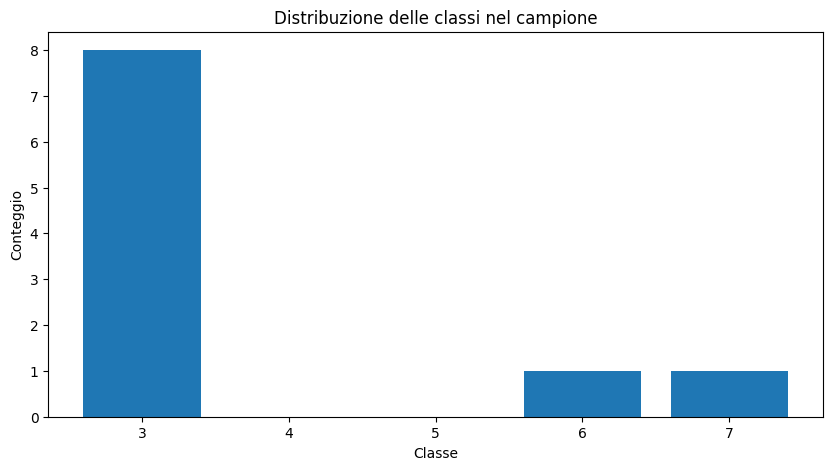

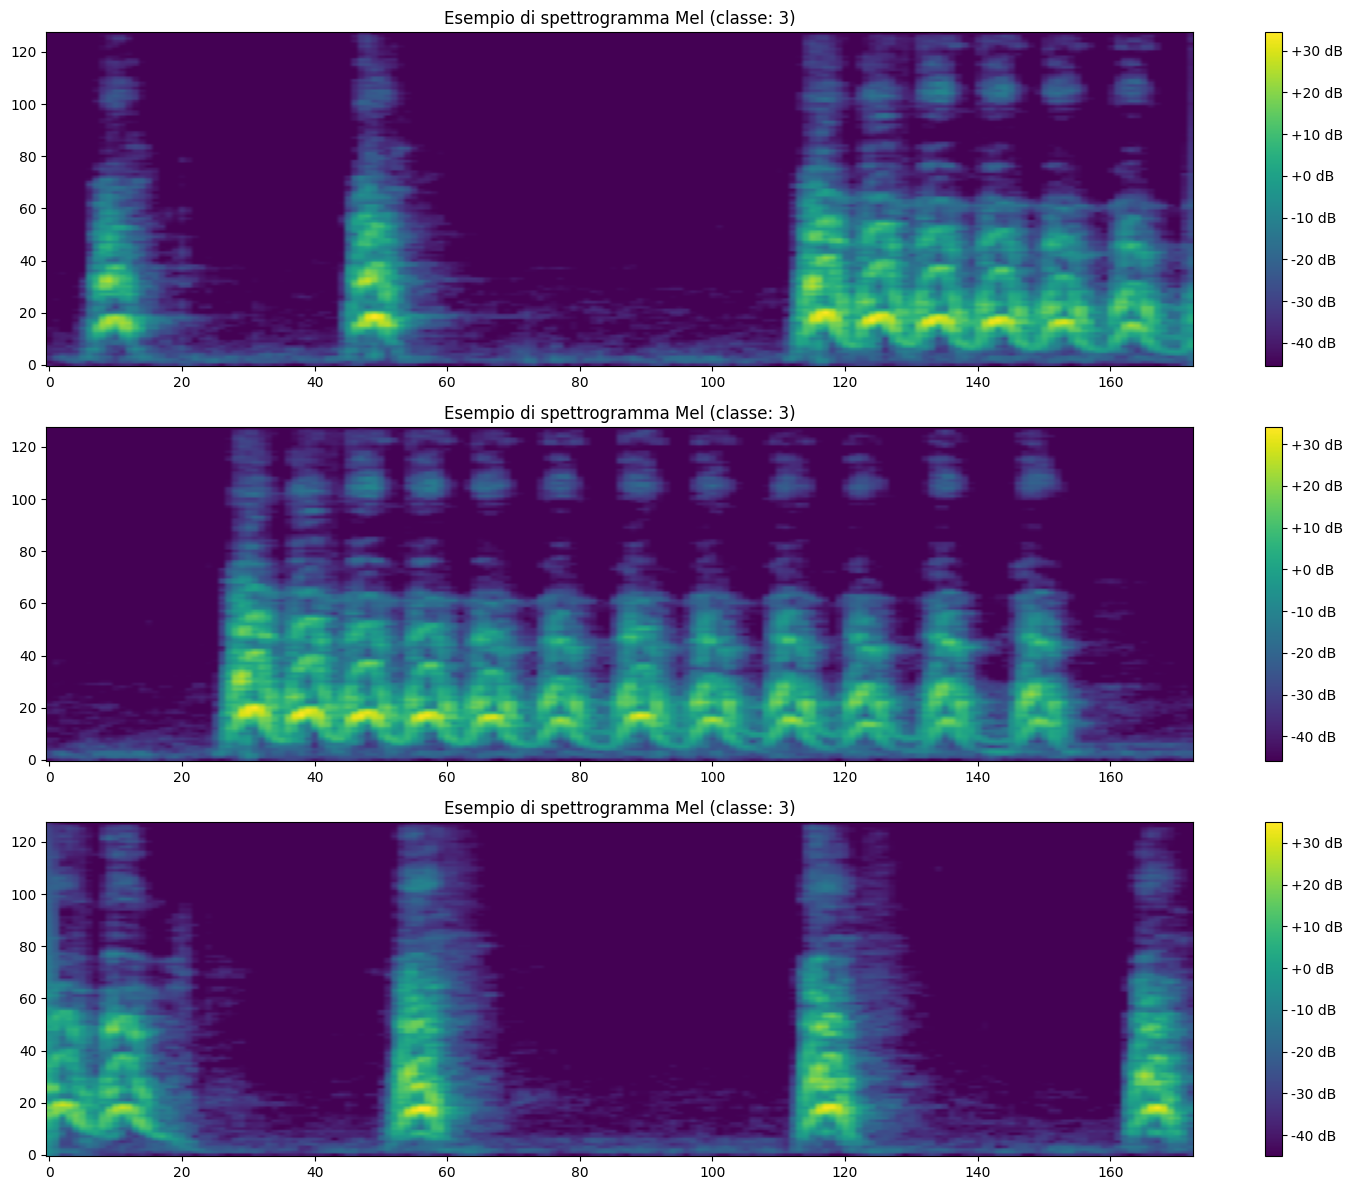

In [5]:
# Carichiamo il contenuto dei fold per ispezionare le dimensioni dei dati
fold_dirs = sorted(glob.glob(os.path.join(features_dir, "fold*")))

if fold_dirs:
    print(f"Trovate {len(fold_dirs)} directory di fold")
    
    try:
        # Carica i dati dal primo fold disponibile
        first_fold = fold_dirs[0]
        print(f"\nCaricamento dati dal fold: {first_fold}")
        
        # Carica solo alcuni file per avere un campione
        sample_files = glob.glob(os.path.join(first_fold, "*.npz"))[:10]
        
        if sample_files:
            # Carica e combina i dati di esempio
            all_features = []
            all_labels = []
            
            for file in sample_files:
                try:
                    features, label = load_fold_data(file)
                    all_features.append(features)
                    all_labels.append(label)
                    print(f"File {os.path.basename(file)}: features shape={features.shape}, label={label}")
                except Exception as e:
                    print(f"Errore nel caricare {os.path.basename(file)}: {e}")
            
            if all_features:
                sample_features = np.vstack(all_features)
                sample_labels = np.array(all_labels)
                
                # Controllo dimensioni e tipi di dati
                print(f"\nDimensione features campione: {sample_features.shape}")
                print(f"Tipo di dati features: {sample_features.dtype}")
                print(f"Range valori features: [{np.min(sample_features)}, {np.max(sample_features)}]")
                print(f"Dimensione labels: {sample_labels.shape}")
                print(f"Tipo di dati labels: {sample_labels.dtype}")
                
                # Verifica delle classi uniche
                unique_classes = np.unique(sample_labels)
                print(f"Classi uniche: {unique_classes}")
                print(f"Numero di classi: {len(unique_classes)}")
                
                # Verifica della distribuzione delle classi
                unique, counts = np.unique(sample_labels, return_counts=True)
                class_dist = dict(zip(unique, counts))
                print(f"\nDistribuzione delle classi nel campione:")
                for cls, count in class_dist.items():
                    print(f"Classe {cls}: {count} esempi")
                
                plt.figure(figsize=(10, 5))
                plt.bar(unique, counts)
                plt.xlabel('Classe')
                plt.ylabel('Conteggio')
                plt.title('Distribuzione delle classi nel campione')
                plt.show()
                
                # Visualizza alcuni spettrogrammi di esempio
                n_examples = min(3, len(sample_features))
                plt.figure(figsize=(15, 4*n_examples))
                for i in range(n_examples):
                    plt.subplot(n_examples, 1, i+1)
                    # Rimozione della dimensione del canale per la visualizzazione
                    spec_to_plot = sample_features[i].squeeze()
                    plt.imshow(spec_to_plot, aspect='auto', origin='lower')
                    plt.colorbar(format='%+2.0f dB')
                    plt.title(f'Esempio di spettrogramma Mel (classe: {sample_labels[i]})')
                plt.tight_layout()
                plt.show()
            else:
                print("Non è stato possibile caricare alcun file di esempio.")
        else:
            print(f"Nessun file NPZ trovato in {first_fold}")
    except Exception as e:
        print(f"Errore durante l'esplorazione dei dati: {str(e)}")
else:
    print("Impossibile esplorare i dati: nessuna directory di fold trovata.")

## 5. Implementazione della Cross-Validation

Implementiamo la k-fold cross-validation per addestrare e valutare il modello. Utilizzeremo i fold già creati per garantire una valutazione robusta del modello.


Fase 1: Caricamento unificato di tutti i dati dal disco...
Caricando fold1...
Caricando fold10...
Caricando fold2...
Caricando fold3...
Caricando fold4...
Caricando fold5...
Caricando fold6...
Caricando fold7...
Caricando fold8...
Caricando fold9...

Caricamento completato. Tutti i dati sono in memoria.

Nel dataset sono presenti 10 classi di suoni urbani.
0: air_conditioner
1: car_horn
2: children_playing
3: dog_bark
4: drilling
5: engine_idling
6: gun_shot
7: jackhammer
8: siren
9: street_music

Fase 3: Avvio della Cross-Validation...

--- Elaborazione Fold 1/10 ---
Fold di validation: fold1
Epoch 1/2
246/246 - 132s - 536ms/step - accuracy: 0.5992 - loss: 1.2583 - val_accuracy: 0.4662 - val_loss: 2.4075
Epoch 2/2
246/246 - 131s - 531ms/step - accuracy: 0.7305 - loss: 0.8186 - val_accuracy: 0.6449 - val_loss: 1.3910
Restoring model weights from the end of the best epoch: 2.
Accuracy sul fold 1: 0.6449

--- Elaborazione Fold 2/10 ---
Fold di validation: fold2
Epoch 1/2
246/246 - 130s 

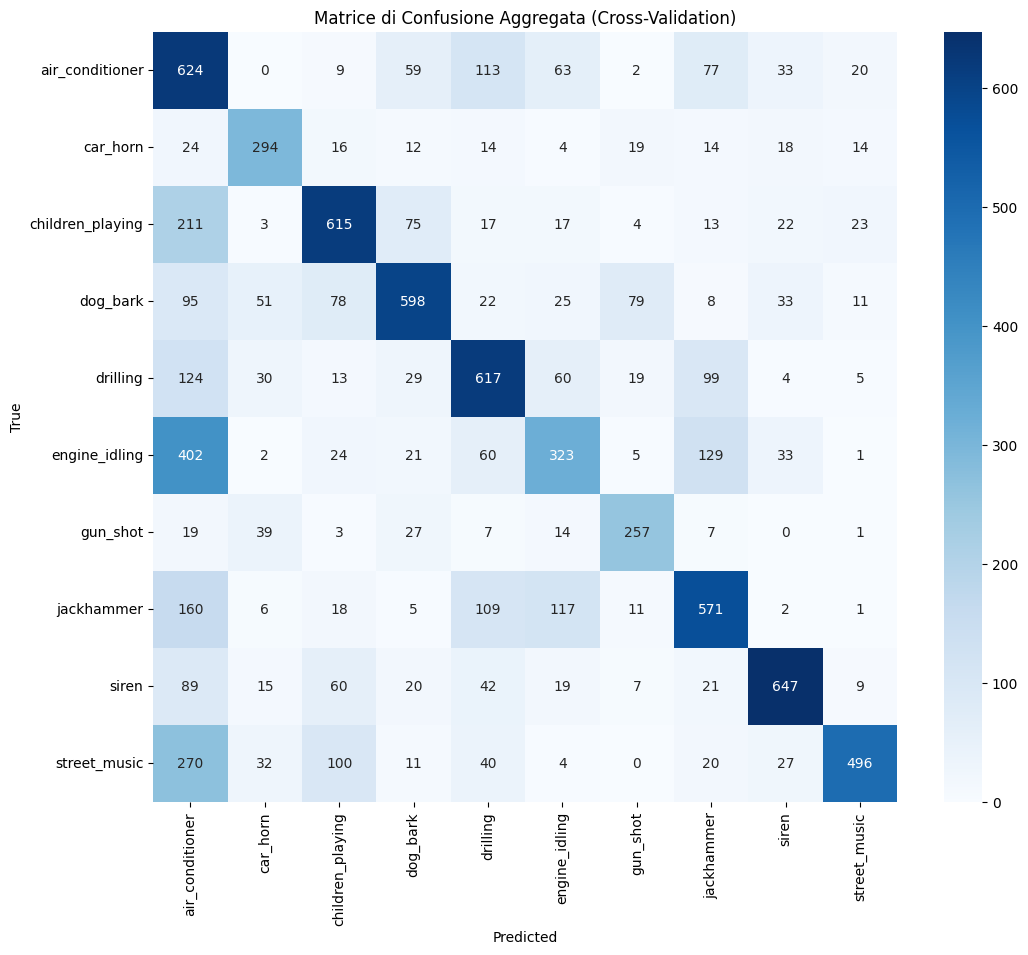


Report di Classificazione Aggregato (Cross-Validation):
                  precision    recall  f1-score   support

 air_conditioner       0.31      0.62      0.41      1000
        car_horn       0.62      0.69      0.65       429
children_playing       0.66      0.61      0.64      1000
        dog_bark       0.70      0.60      0.64      1000
        drilling       0.59      0.62      0.60      1000
   engine_idling       0.50      0.32      0.39      1000
        gun_shot       0.64      0.69      0.66       374
      jackhammer       0.60      0.57      0.58      1000
           siren       0.79      0.70      0.74       929
    street_music       0.85      0.50      0.63      1000

        accuracy                           0.58      8732
       macro avg       0.63      0.59      0.60      8732
    weighted avg       0.62      0.58      0.59      8732


Fase 5: Addestramento del modello finale su tutto il dataset...
Dimensione totale del dataset: (8732, 128, 173, 1)

Addestramen

In [ ]:
# ==============================================================================
# BLOCCO 1: ADDESTRAMENTO CON CROSS-VALIDATION E SALVATAGGIO MODELLO FINALE
# ==============================================================================

# Pulizia generale prima di iniziare
import os
import gc
import json
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

tf.keras.backend.clear_session()
gc.collect()

# --- FASE 1: CARICAMENTO UNIFICATO DEI DATI ---
# Questa fase è cruciale per l'efficienza. Carichiamo tutto una sola volta.
print("="*50)
print("Fase 1: Caricamento unificato di tutti i dati dal disco...")
print("="*50)

all_data = {}
fold_dirs = sorted(glob.glob(os.path.join(features_dir, "fold*")))

for fold_dir in fold_dirs:
    fold_name = os.path.basename(fold_dir)
    print(f"Caricando {fold_name}...")
    try:
        X_fold, y_fold = collect_fold_data(fold_dir)
        all_data[fold_name] = (X_fold, y_fold)
    except Exception as e:
        print(f"Errore nel caricamento del fold {fold_name}: {e}")

print("\nCaricamento completato. Tutti i dati sono in memoria.")

# --- FASE 2: DEFINIZIONE DEI PARAMETRI E STRUTTURE DATI ---
# Usiamo il file CSV originale per le informazioni sulle classi
META_FILE = "../data/raw/UrbanSound8K.csv"  # Assicurati che questo percorso sia corretto
df_meta = pd.read_csv(META_FILE)
class_map_df = df_meta[['classID', 'class']].drop_duplicates().sort_values('classID')
class_names = dict(zip(class_map_df.classID, class_map_df['class']))
num_classes = len(class_names)
class_labels = [class_names[i] for i in range(num_classes)] # Lista ordinata dei nomi delle classi

print(f"\nNel dataset sono presenti {num_classes} classi di suoni urbani.")
for idx, name in class_names.items():
    print(f"{idx}: {name}")

# Parametri
batch_size = 32
epochs = 2  # Un numero più realistico per un buon addestramento
num_folds = len(fold_dirs)
input_shape = list(all_data.values())[0][0][0].shape # Ottieni la forma da un campione

# Liste per i risultati della CV
fold_accuracies = []
all_y_true_cv = []
all_y_pred_cv = []

# --- FASE 3: CICLO DI CROSS-VALIDATION ---
print("\n" + "="*50)
print("Fase 3: Avvio della Cross-Validation...")
print("="*50)

for fold_idx in range(num_folds):
    print(f"\n--- Elaborazione Fold {fold_idx + 1}/{num_folds} ---")
    
    tf.keras.backend.clear_session()
    gc.collect()

    val_fold_name = f"fold{fold_idx + 1}"
    print(f"Fold di validation: {val_fold_name}")
    X_val, y_val = all_data[val_fold_name]
    
    X_train_parts = [data[0] for name, data in all_data.items() if name != val_fold_name]
    y_train_parts = [data[1] for name, data in all_data.items() if name != val_fold_name]
        
    X_train = np.vstack(X_train_parts)
    y_train = np.concatenate(y_train_parts)

    model = create_model(input_shape, num_classes)
    callbacks = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)]
    
    model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, 
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=2)
    
    _, accuracy = model.evaluate(X_val, y_val, verbose=0)
    fold_accuracies.append(accuracy)
    print(f"Accuracy sul fold {fold_idx + 1}: {accuracy:.4f}")
    
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    all_y_true_cv.extend(y_val)
    all_y_pred_cv.extend(y_pred)
    del model, X_train, y_train, X_val, y_val

# --- FASE 4: RISULTATI COMPLESSIVI DELLA CV ---
print("\n" + "="*50)
print("RISULTATI COMPLESSIVI DELLA CROSS-VALIDATION")
print("="*50)
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
print(f"\nAccuracy media stimata: {mean_acc:.4f} ± {std_acc:.4f}\n")

conf_matrix_cv = confusion_matrix(all_y_true_cv, all_y_pred_cv)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_cv, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice di Confusione Aggregata (Cross-Validation)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print("\nReport di Classificazione Aggregato (Cross-Validation):")
print(classification_report(all_y_true_cv, all_y_pred_cv, target_names=class_labels))



In [11]:
# Import delle librerie necessarie se non già presenti
import os
import gc
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- FASE 1: PREPARAZIONE DEI DATI E DEGLI ID SORGENTE ---
print("="*50)
print("Fase 1: Preparazione dei dati e degli ID sorgente...")
print("="*50)

# Carica i metadati per ottenere gli ID dei file originali (fsID)
META_FILE = "../data/raw/UrbanSound8K.csv"  # Assicurati che il percorso sia corretto
df_meta = pd.read_csv(META_FILE)

# Crea una mappatura: nome_file -> fsID
# 'slice_file_name' è il nome del file (es. "7383-3-0-0.wav")
# 'fsID' è l'ID della registrazione originale (es. 7383)
filename_to_fsid = dict(zip(df_meta.slice_file_name, df_meta.fsID))

# Estrai tutti gli ID unici delle registrazioni originali
all_original_ids = df_meta['fsID'].unique()
print(f"Trovati {len(all_original_ids)} file audio originali unici.")

# --- FASE 2: CREAZIONE DELLO SPLIT 80/20 BASATO SUGLI ID SORGENTE ---
# Dividiamo gli ID, non i singoli file, per garantire la separazione.
train_ids, test_ids = train_test_split(
    all_original_ids, 
    test_size=0.2,       # Splitting 80/20
    random_state=seed    # Per la riproducibilità
)

train_ids_set = set(train_ids)
test_ids_set = set(test_ids)

print(f"Numero di ID per il training: {len(train_ids_set)}")
print(f"Numero di ID per il test: {len(test_ids_set)}")

# --- FASE 3: ASSEMBLAGGIO DEI SET DI TRAINING E TEST ---
# Itera su tutti i file .npz e assegnali al set giusto in base al loro fsID.

# 'all_data' dovrebbe essere già in memoria dal blocco di CV.
# Se non lo è, ricaricalo (codice omesso per brevità, ma presente nel blocco precedente).
if 'all_data' not in globals() or not all_data:
    raise ValueError("Il dizionario 'all_data' non è in memoria. Esegui prima il blocco di caricamento.")

X_train_final, y_train_final = [], []
X_test_final, y_test_final = [], []

print("\nAssemblaggio dei set di training e test...")
for fold_name, (X_fold, y_fold) in all_data.items():
    # Trova i nomi dei file per questo fold dal DataFrame
    fold_num = int(fold_name.replace('fold', ''))
    filenames_in_fold = df_meta[df_meta['fold'] == fold_num]['slice_file_name'].tolist()
    
    # Assicurati che il numero di file corrisponda
    if len(filenames_in_fold) != len(X_fold):
        print(f"Attenzione: discrepanza nel numero di file per {fold_name}. Potrebbero esserci problemi.")
        continue

    for i, filename_wav in enumerate(filenames_in_fold):
        # Il nome nel CSV è .wav, noi abbiamo .npz, ma l'ID è lo stesso
        fsid = filename_to_fsid.get(filename_wav)
        
        if fsid in train_ids_set:
            X_train_final.append(X_fold[i])
            y_train_final.append(y_fold[i])
        elif fsid in test_ids_set:
            X_test_final.append(X_fold[i])
            y_test_final.append(y_fold[i])

# Converte le liste di array in singoli array NumPy
X_train_final = np.array(X_train_final)
y_train_final = np.array(y_train_final)
X_test_final = np.array(X_test_final)
y_test_final = np.array(y_test_final)

# Rimuovi la dimensione extra aggiunta durante il caricamento (se presente)
# La forma dovrebbe essere (N, altezza, larghezza, canali)
X_train_final = X_train_final.reshape(-1, *input_shape)
X_test_final = X_test_final.reshape(-1, *input_shape)

print(f"\nDimensione set di Training finale: {X_train_final.shape} (Esempi: {len(y_train_final)})")
print(f"Dimensione set di Test finale: {X_test_final.shape} (Esempi: {len(y_test_final)})")

# --- FASE 4: ADDESTRAMENTO, VALUTAZIONE E SALVATAGGIO ---
print("\n" + "="*50)
print("Fase 4: Addestramento e valutazione del modello finale...")
print("="*50)

tf.keras.backend.clear_session()
gc.collect()

final_model = create_model(input_shape, num_classes)
final_callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1)
]

history = final_model.fit(
    X_train_final, y_train_final,
    batch_size=batch_size,
    epochs=2, # Aumentato, EarlyStopping gestirà l'arresto
    validation_data=(X_test_final, y_test_final),
    callbacks=final_callbacks,
    verbose=1
)

Fase 1: Preparazione dei dati e degli ID sorgente...
Trovati 1297 file audio originali unici.
Numero di ID per il training: 1037
Numero di ID per il test: 260

Assemblaggio dei set di training e test...

Dimensione set di Training finale: (6934, 128, 173, 1) (Esempi: 6934)
Dimensione set di Test finale: (1798, 128, 173, 1) (Esempi: 1798)

Fase 4: Addestramento e valutazione del modello finale...
Epoch 1/2
217/217 ━━━━━━━━━━━━━━━━━━━━ 121s 547ms/step - accuracy: 0.4989 - loss: 1.6261 - val_accuracy: 0.4410 - val_loss: 5.2213 - learning_rate: 0.0010
Epoch 2/2
217/217 ━━━━━━━━━━━━━━━━━━━━ 120s 552ms/step - accuracy: 0.7513 - loss: 0.7571 - val_accuracy: 0.5139 - val_loss: 5.1602 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.



Fase 5: Valutazione finale del modello...

Performance sul Test Set (split 80/20 stratificato per ID):
  - Loss: 5.1602
  - Accuracy: 0.5139

Performance media stimata dalla CV: 0.5781

Report di Classificazione sul Test Set:
                  precision    recall  f1-score   support

 air_conditioner       0.29      0.52      0.37       207
        car_horn       0.72      0.85      0.78       165
children_playing       0.58      0.69      0.63       165
        dog_bark       0.63      0.53      0.57       190
        drilling       0.46      0.77      0.58       205
   engine_idling       0.22      0.27      0.25       142
        gun_shot       0.57      0.05      0.09        84
      jackhammer       0.72      0.38      0.50       293
           siren       0.65      0.57      0.61       105
    street_music       0.90      0.37      0.52       242

        accuracy                           0.51      1798
       macro avg       0.57      0.50      0.49      1798
    weighted avg 

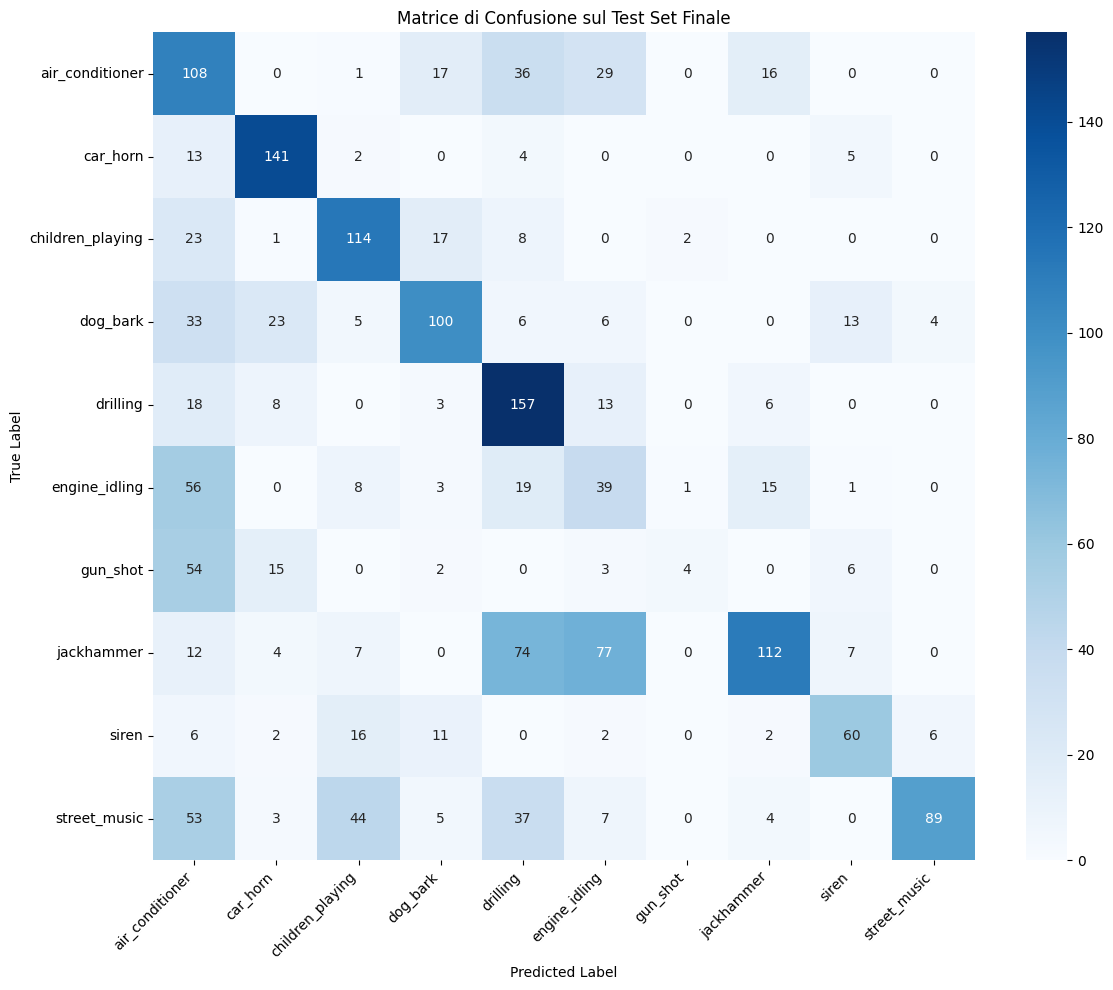


Fase 6: Salvataggio del modello e dei metadati...
Modello finale salvato in: ../models\urban_sound_classifier_final.keras
Metadati del modello salvati in: ../models\model_metadata.json


In [12]:
# --- FASE 5: VALUTAZIONE FINALE E REPORTING ---
print("\n" + "="*50)
print("Fase 5: Valutazione finale del modello...")
print("="*50)

# Valutazione finale sul test set
final_loss, final_accuracy = final_model.evaluate(X_test_final, y_test_final, verbose=0)
print(f"\nPerformance sul Test Set (split 80/20 stratificato per ID):")
print(f"  - Loss: {final_loss:.4f}")
print(f"  - Accuracy: {final_accuracy:.4f}\n")

# Confronto con la stima della Cross-Validation
mean_acc_cv = np.mean(fold_accuracies) if 'fold_accuracies' in globals() and fold_accuracies else 0
print(f"Performance media stimata dalla CV: {mean_acc_cv:.4f}")

# Predizioni per analisi dettagliata
y_pred_final = np.argmax(final_model.predict(X_test_final, verbose=0), axis=1)

# Report di Classificazione
report = classification_report(y_test_final, y_pred_final, target_names=class_labels)
print("\nReport di Classificazione sul Test Set:")
print(report)

# Matrice di Confusione
conf_matrix = confusion_matrix(y_test_final, y_pred_final)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice di Confusione sul Test Set Finale')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- FASE 6: SALVATAGGIO DEL MODELLO E DEI METADATI ---
print("\n" + "="*50)
print("Fase 6: Salvataggio del modello e dei metadati...")
print("="*50)

save_dir = "../models"
os.makedirs(save_dir, exist_ok=True)

model_filename = "urban_sound_classifier_final.keras"
model_path = os.path.join(save_dir, model_filename)
final_model.save(model_path)
print(f"Modello finale salvato in: {model_path}")

# Prepara i metadati da salvare
# Assicurati che le variabili fold_accuracies e std_acc esistano
mean_acc_cv = np.mean(fold_accuracies) if 'fold_accuracies' in globals() and fold_accuracies else None
std_acc_cv = np.std(fold_accuracies) if 'fold_accuracies' in globals() and fold_accuracies else None

model_metadata = {
    "model_filename": model_filename,
    "input_shape": list(input_shape),
    "num_classes": int(num_classes),
    "class_names": class_names,
    "final_test_set_performance": {
        "split_strategy": "80/20 split on original source IDs (fsID)",
        "accuracy": final_accuracy,
        "loss": final_loss
    },
    "estimated_cv_performance": {
        "mean_accuracy": mean_acc_cv,
        "std_accuracy": std_acc_cv
    },
    "training_date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

metadata_filename = "model_metadata.json"
metadata_path = os.path.join(save_dir, metadata_filename)
with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)
    
print(f"Metadati del modello salvati in: {metadata_path}")

### Blocco 2: Caricamento del Modello e Report delle Performance sul Test Set

Fase 1: Caricamento del modello e dei metadati salvati...
Modello e metadati caricati con successo.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    11,010,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,320,480 (127.11 MB)

 Trainable params: 11,106,506 (42.37 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 22,213,014 (84.74 MB)


Fase 2: Ricreazione del set di test...
Caricamento dei dati necessari per il test set...
Set di test ricreato con 1798 campioni.

Fase 3: Esecuzione delle predizioni e generazione dei report...
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step

Report di Classificazione sul Test Set:
                  precision    recall  f1-score   support

 air_conditioner       0.29      0.52      0.37       207
        car_horn       0.72      0.85      0.78       165
children_playing       0.58      0.69      0.63       165
        dog_bark       0.63      0.53      0.57       190
        drilling       0.46      0.77      0.58       205
   engine_idling       0.22      0.27      0.25       142
        gun_shot       0.57      0.05      0.09        84
      jackhammer       0.72      0.38      0.50       293
           siren       0.65      0.57      0.61       105
    street_music       0.90      0.37      0.52       242

        accuracy                           0.51      1798
       macro avg       0.5

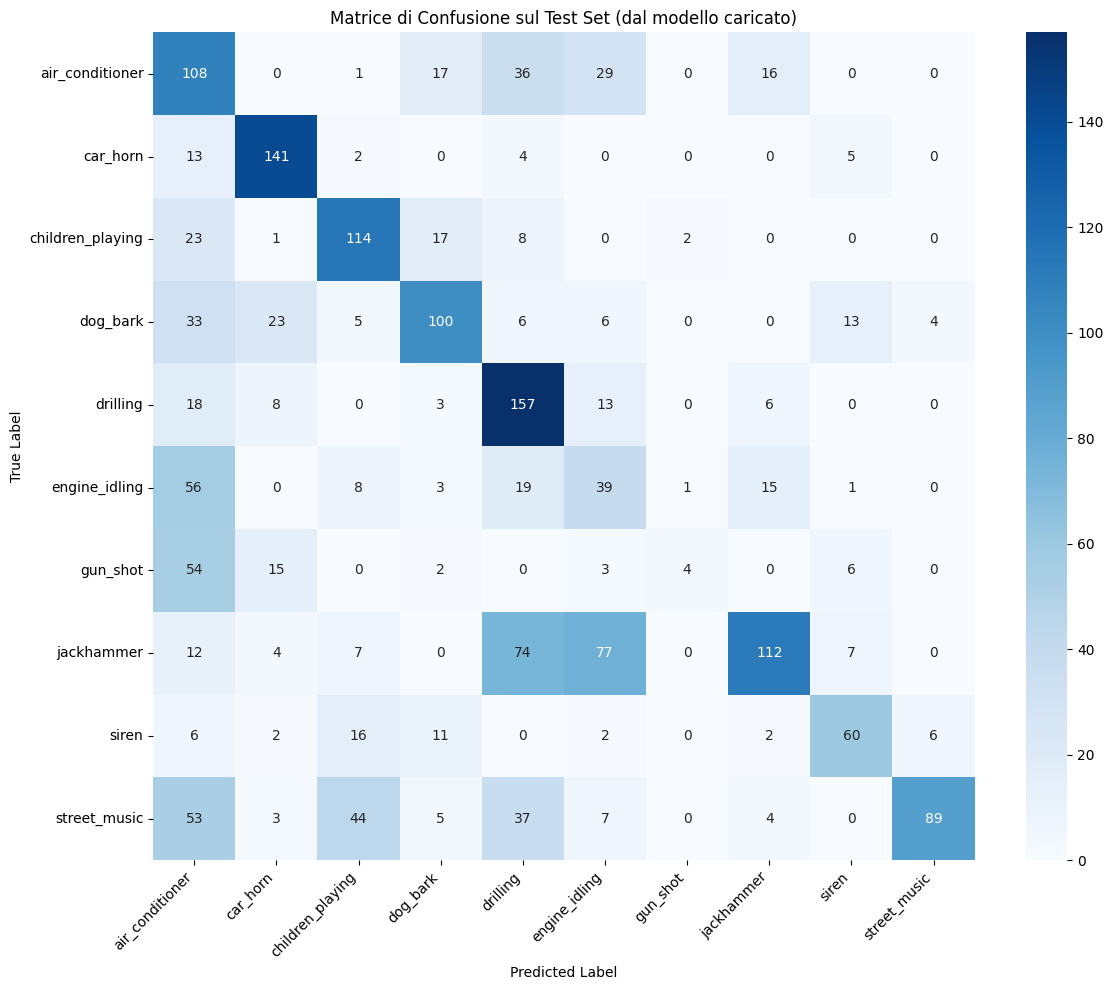


Accuracy complessiva calcolata: 0.5139
Accuracy registrata nei metadati: 0.5139


In [14]:
# ==============================================================================
# BLOCCO 2: CARICAMENTO DEL MODELLO SALVATO E REPORTING
# ==============================================================================

# Import delle librerie necessarie
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- FASE 1: CARICAMENTO MODELLO E METADATI DAL DISCO ---
print("="*50)
print("Fase 1: Caricamento del modello e dei metadati salvati...")
print("="*50)

# Definisci i percorsi dei file salvati
save_dir = "../models"
metadata_path = os.path.join(save_dir, "model_metadata.json")

try:
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    
    model_path = os.path.join(save_dir, metadata['model_filename'])
    loaded_model = tf.keras.models.load_model(model_path)
    
    print("Modello e metadati caricati con successo.")
    loaded_model.summary()
except Exception as e:
    print(f"Errore nel caricamento: Assicurati di aver eseguito prima il Blocco 1.")
    print(f"Dettagli errore: {e}")
    raise

# --- FASE 2: PREPARAZIONE DEL TEST SET (RIPRODUZIONE DELLO SPLIT ORIGINALE) ---
# Dobbiamo ricreare lo stesso identico test set usato durante l'addestramento
# per avere una valutazione coerente.
print("\n" + "="*50)
print("Fase 2: Ricreazione del set di test...")
print("="*50)

# Carica i metadati per ottenere gli ID
META_FILE = "../data/raw/UrbanSound8K.csv"
df_meta = pd.read_csv(META_FILE)
all_original_ids = df_meta['fsID'].unique()

# Usa lo stesso random_state per ottenere lo stesso split
_, test_ids = train_test_split(all_original_ids, test_size=0.2, random_state=42)
test_ids_set = set(test_ids)

# Carica solo i dati necessari per il test set per risparmiare memoria
print("Caricamento dei dati necessari per il test set...")
X_test, y_test = [], []
filename_to_fsid = dict(zip(df_meta.slice_file_name, df_meta.fsID))
all_files = glob.glob(os.path.join(features_dir, "fold*/*.npz"))

for file_path in all_files:
    filename_wav = os.path.basename(file_path).replace('.npz', '.wav')
    fsid = filename_to_fsid.get(filename_wav)
    if fsid in test_ids_set:
        features, label = load_fold_data(file_path)
        X_test.append(features)
        y_test.append(label)

X_test_loaded = np.array(X_test).reshape(-1, *metadata['input_shape'])
y_test_loaded = np.array(y_test)

print(f"Set di test ricreato con {len(X_test_loaded)} campioni.")

# --- FASE 3: PREDIZIONE E VALUTAZIONE ---
print("\n" + "="*50)
print("Fase 3: Esecuzione delle predizioni e generazione dei report...")
print("="*50)

# Esegui le predizioni sul test set
y_pred = np.argmax(loaded_model.predict(X_test_loaded, verbose=1), axis=1)

# Estrai informazioni dai metadati caricati
class_names_dict = {int(k): v for k, v in metadata['class_names'].items()}
class_labels = [class_names_dict[i] for i in sorted(class_names_dict.keys())]

# Report di classificazione
print("\nReport di Classificazione sul Test Set:")
print(classification_report(y_test_loaded, y_pred, target_names=class_labels))

# Matrice di confusione
conf_matrix = confusion_matrix(y_test_loaded, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matrice di Confusione sul Test Set (dal modello caricato)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Stampa l'accuracy complessiva per conferma
accuracy = accuracy_score(y_test_loaded, y_pred)
print(f"\nAccuracy complessiva calcolata: {accuracy:.4f}")
print(f"Accuracy registrata nei metadati: {metadata['final_test_set_performance']['accuracy']:.4f}")